# RQ3: Effect of Feature Scaling

This section evaluates how feature scaling impacts model performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [3]:
df = pd.read_csv("/kaggle/input/datasets/imranalishahh/marketing-and-product-performance-dataset/marketing_and_product_performance.csv")

In [4]:
df["Target"] = (df["Revenue_Generated"] > df["Revenue_Generated"].median()).astype(int)

In [5]:
df = df.drop(columns=["Revenue_Generated"], errors='ignore')
df = df.fillna(df.mean(numeric_only=True))
df = pd.get_dummies(df, drop_first=True)

# reduce size
df = df.sample(2000, random_state=42)

In [6]:
X = df.drop("Target", axis=1)
y = df["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
model = LogisticRegression(max_iter=200, solver='liblinear')

model.fit(X_train, y_train)
pred1 = model.predict(X_test)

acc_without = accuracy_score(y_test, pred1)

In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model.fit(X_train_scaled, y_train)
pred2 = model.predict(X_test_scaled)

acc_with = accuracy_score(y_test, pred2)

In [9]:
results = pd.DataFrame({
    "Method": ["Without Scaling", "With Scaling"],
    "Accuracy": [acc_without, acc_with]
})

results.to_csv("/kaggle/working/RQ3_table.csv", index=False)

results

,Method,Accuracy
0,Without Scaling,0.4975
1,With Scaling,0.5150


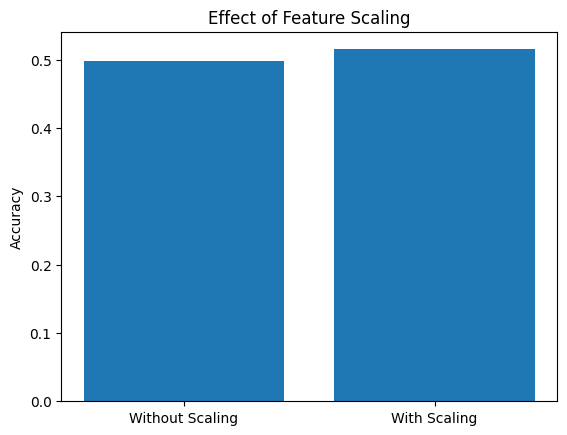

In [ ]:
plt.figure()
plt.bar(results["Method"], results["Accuracy"])
plt.title("Effect of Feature Scaling")

plt.xlabel("Method")
plt.ylabel("Accuracy")

plt.savefig("/kaggle/working/RQ3_figure.pdf")

plt.show()

## Results Interpretation

Feature scaling improves the performance of Logistic Regression by normalizing the range of features. This helps the model converge better and produce more accurate predictions.

In [11]:
import os
os.listdir('/kaggle/working')

['RQ3_figure.pdf', '.virtual_documents', 'RQ3_table.csv']